<a href="https://colab.research.google.com/github/Krish0618/house-price-prediction-linear-regression/blob/main/task1_ml_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading California Housing Dataset...

Dataset Loaded Successfully!

First 5 Rows
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


Dataset Shape
(20640, 9)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   House

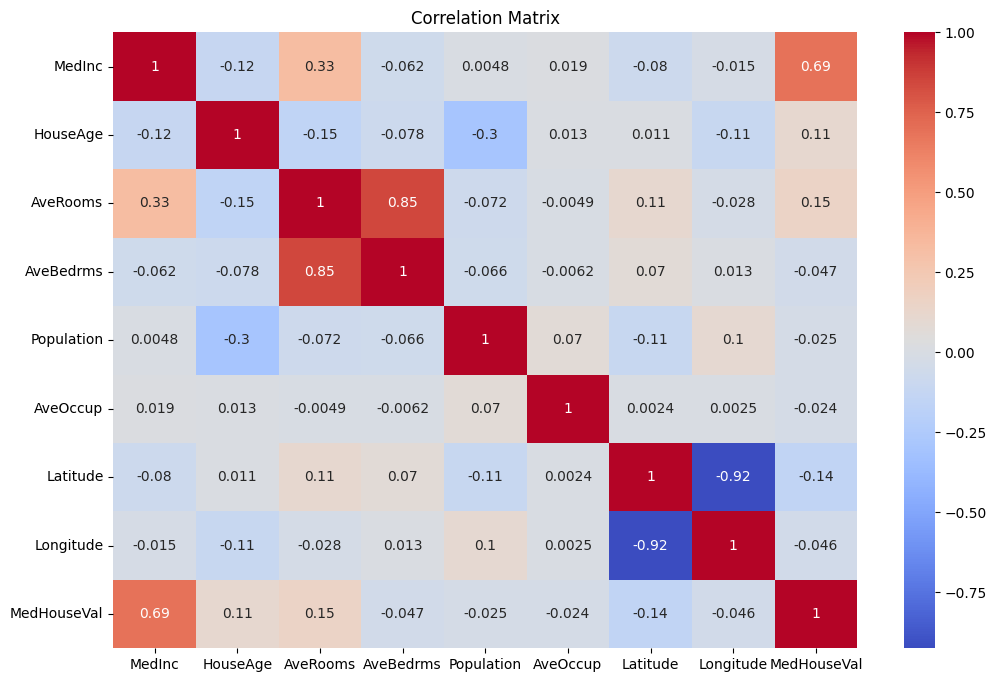

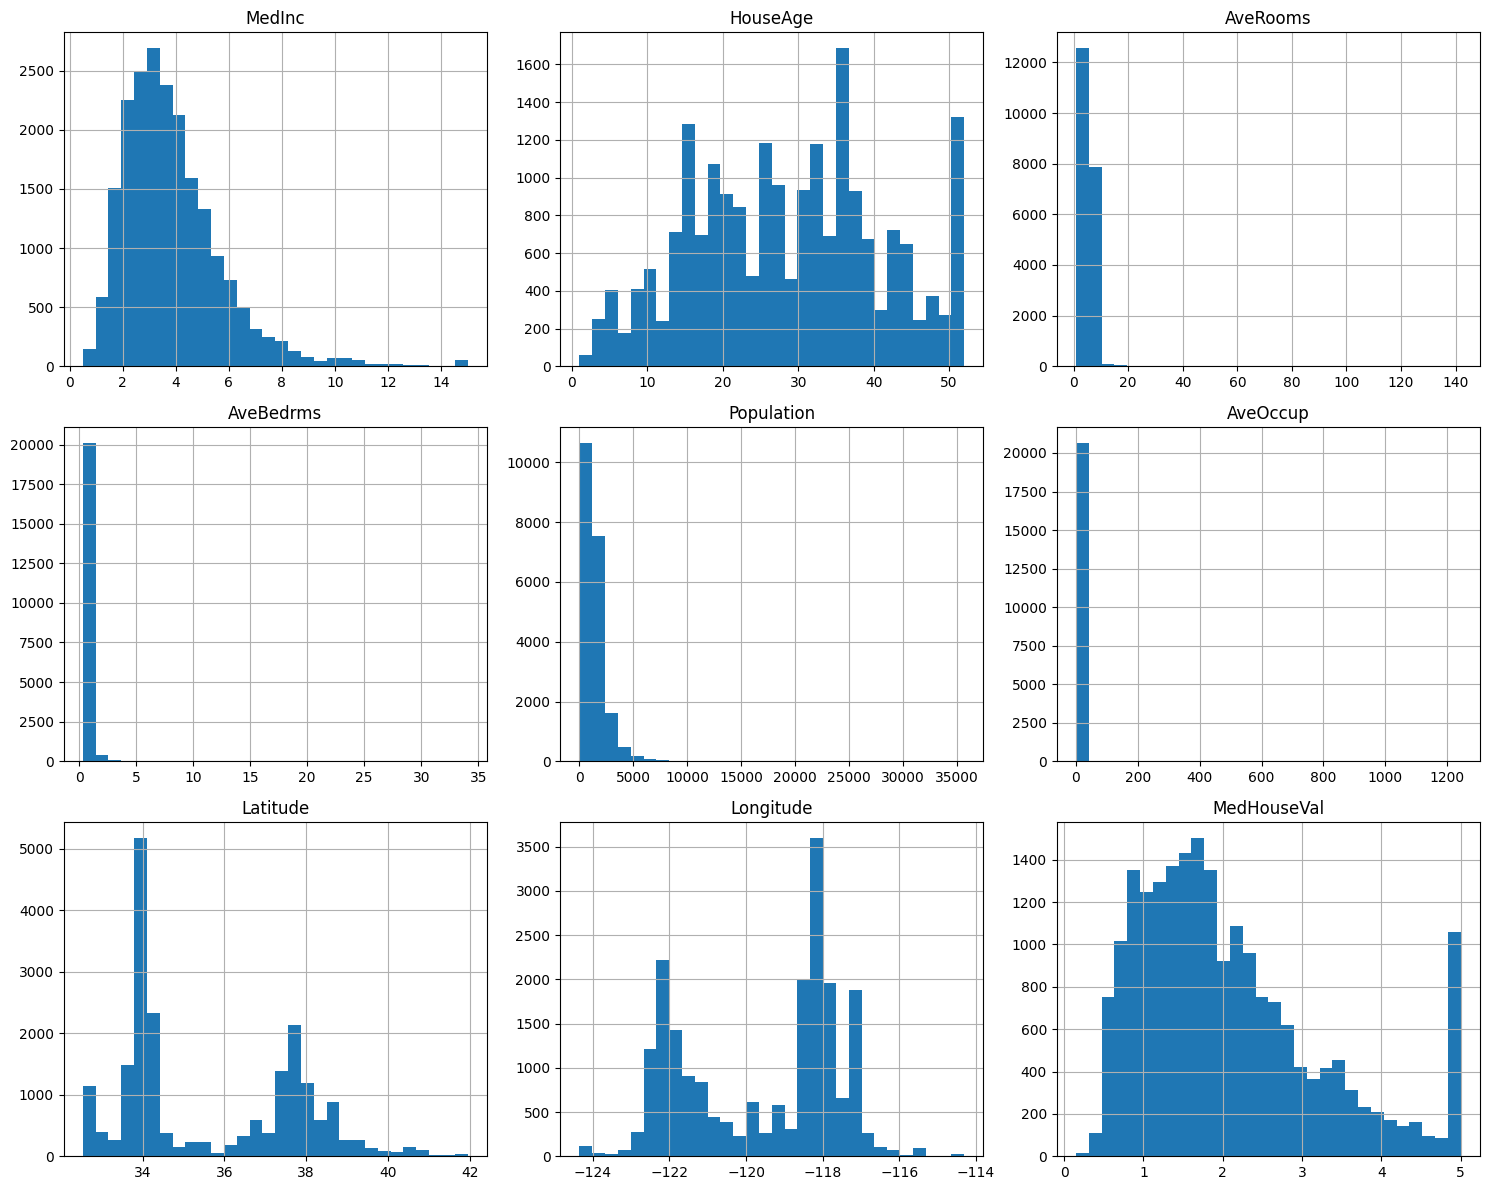

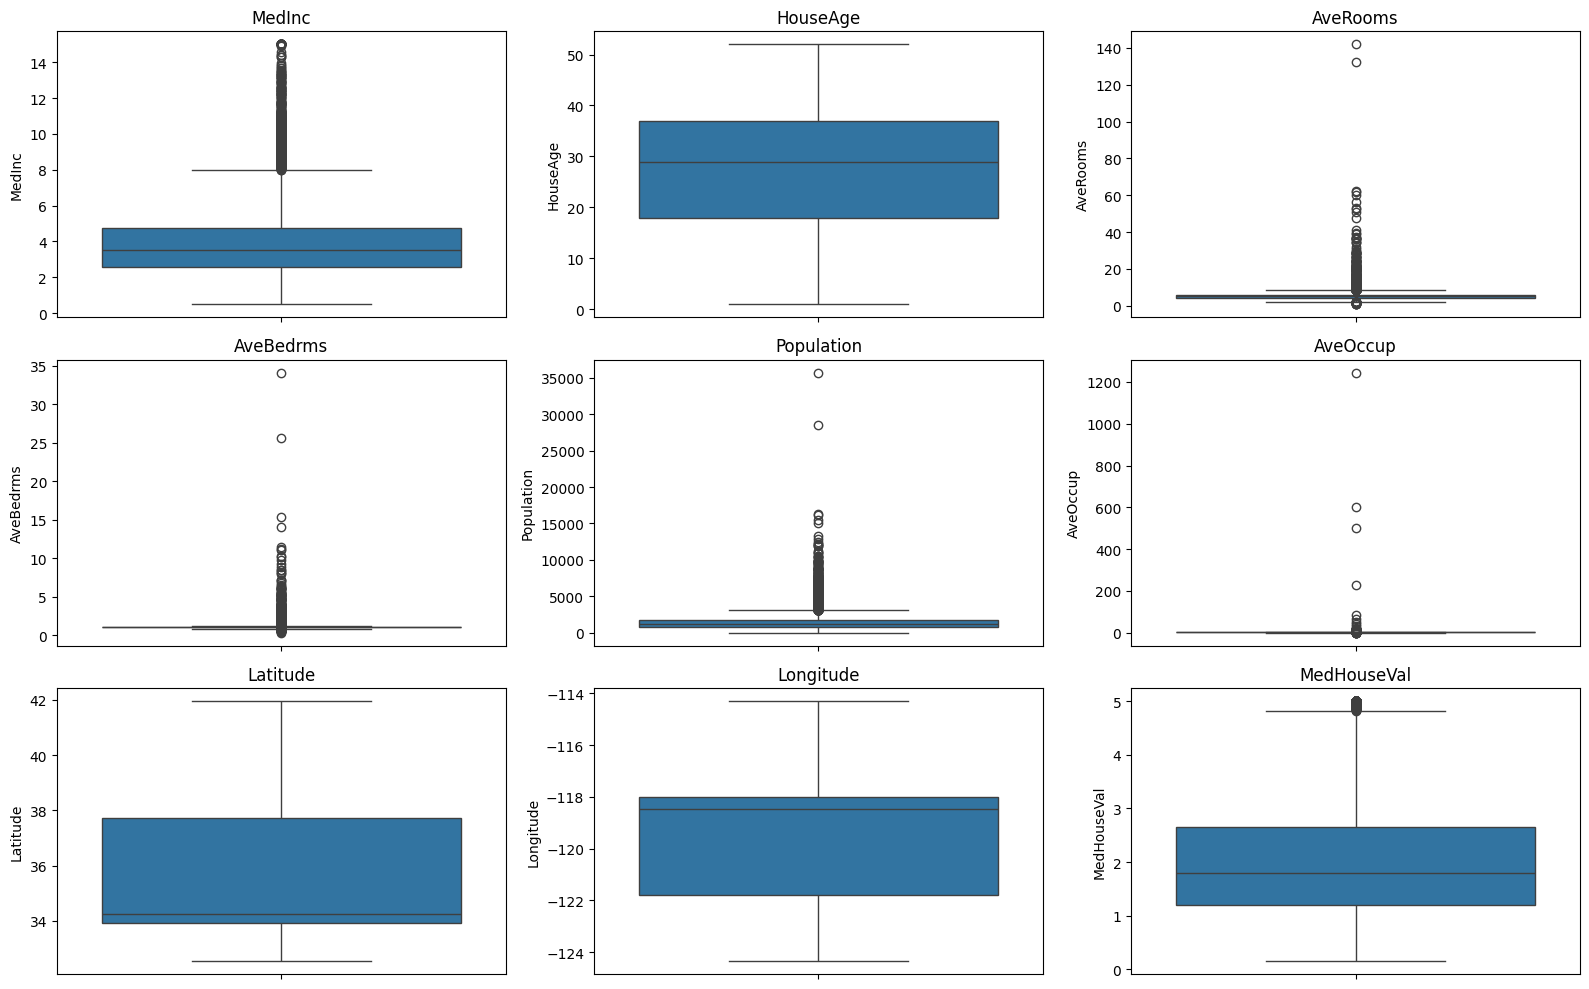

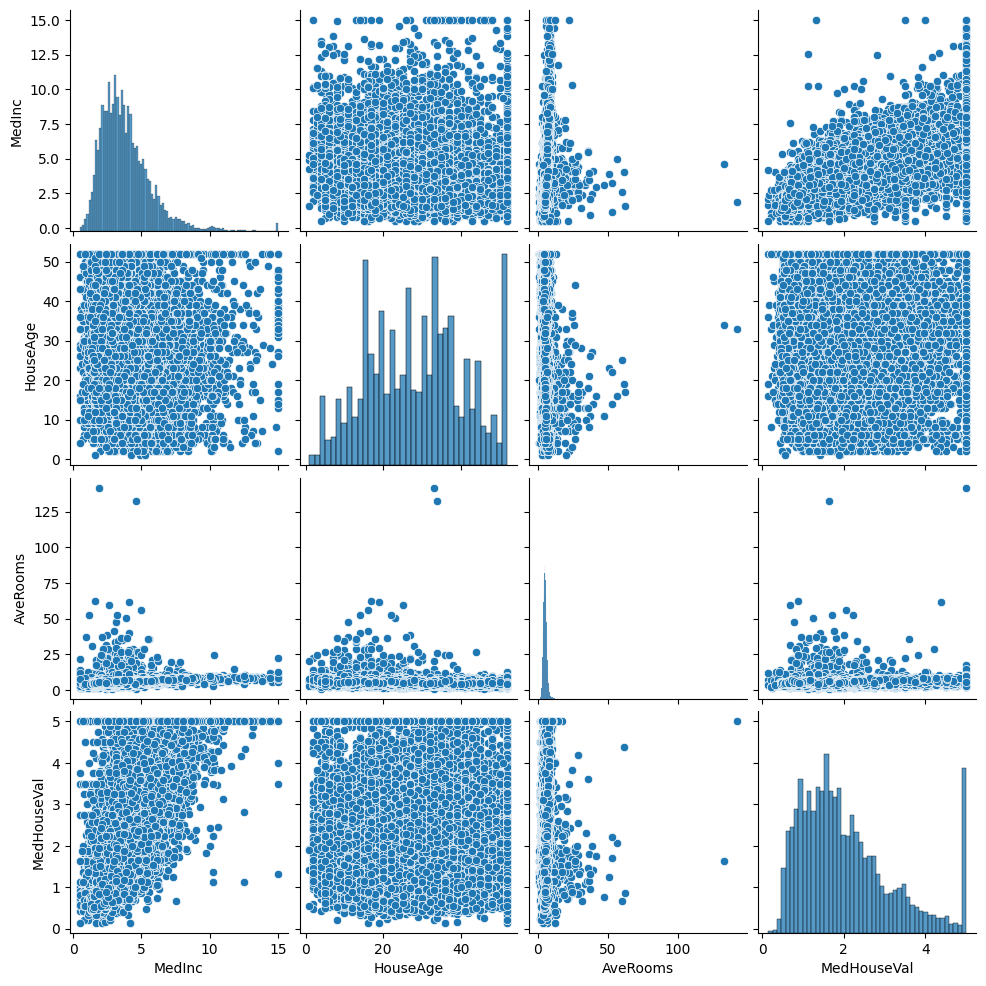


Features Shape : (20640, 8)
Target Shape : (20640,)

Training Data : (16512, 8)
Testing Data : (4128, 8)

Model Trained Successfully!

Model Coefficients
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708

First 10 Predictions
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


Model Evaluation
Mean Absolute Error (MAE): 0.5332001304956553
Root Mean Squared Error (RMSE): 0.7455813830127764
R2 Score: 0.5757877060324508


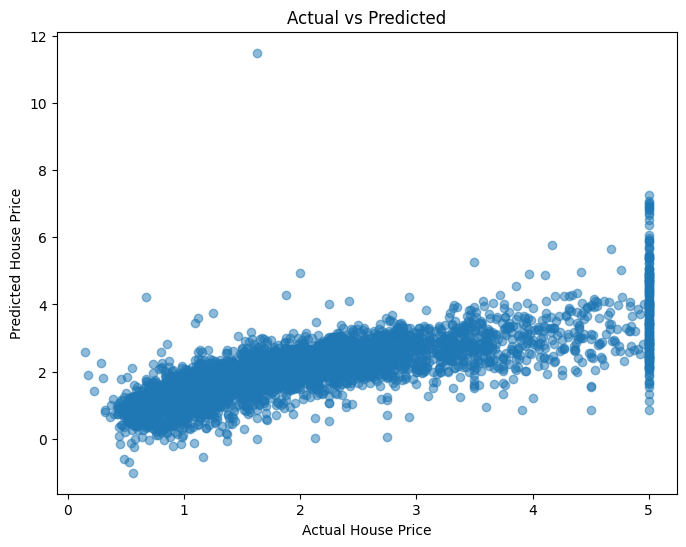

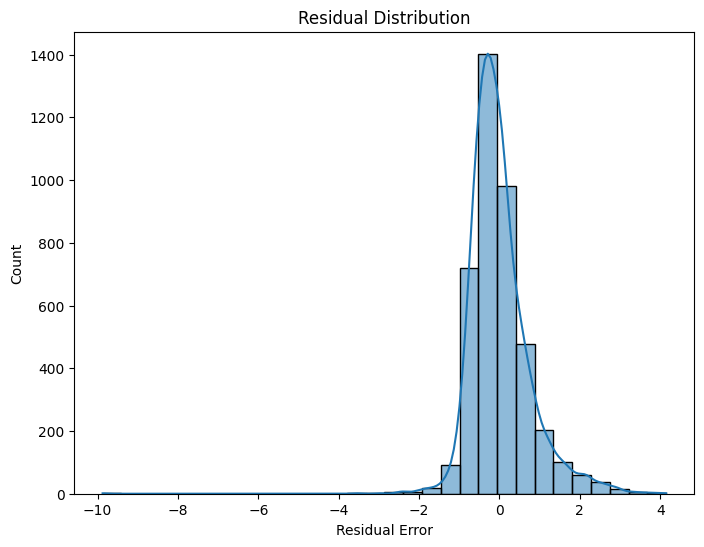


Model Saved Successfully!
Saved Model Loaded Successfully!

Predicted House Price = 4.151943055154284


PROJECT SUMMARY

Dataset               : California Housing
Algorithm             : Linear Regression

Training Samples      : 16512
Testing Samples       : 4128

Mean Absolute Error   : 0.5332
Root Mean Square Error: 0.7456
R2 Score              : 0.5758

Project Completed Successfully.



In [1]:
# ==========================================================
# AI & ML Task 1
# House Price Prediction using Linear Regression
# California Housing Dataset
# ==========================================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

warnings.filterwarnings("ignore")

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================================
# Load Dataset
# ==========================================================

print("="*60)
print("Loading California Housing Dataset...")
print("="*60)

housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("\nDataset Loaded Successfully!\n")

# ==========================================================
# Display Dataset
# ==========================================================

print("="*60)
print("First 5 Rows")
print("="*60)

print(df.head())

print("\n")

print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

print(df.info())

print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)

print(df.describe())

print("\n")

print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())

print("\n")

print("="*60)
print("Duplicate Rows")
print("="*60)

print(df.duplicated().sum())

# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ==========================================================
# Histograms
# ==========================================================

df.hist(figsize=(15,12),bins=30)
plt.tight_layout()
plt.show()

# ==========================================================
# Boxplots
# ==========================================================

plt.figure(figsize=(16,10))

for i,column in enumerate(df.columns):

    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[column])

    plt.title(column)

plt.tight_layout()
plt.show()

# ==========================================================
# Pairplot
# ==========================================================

sns.pairplot(df[['MedInc','HouseAge','AveRooms','MedHouseVal']])
plt.show()

# ==========================================================
# Feature Selection
# ==========================================================

X = df.drop("MedHouseVal",axis=1)

y = df["MedHouseVal"]

print("\nFeatures Shape :",X.shape)
print("Target Shape :",y.shape)

# ==========================================================
# Train Test Split
# ==========================================================

X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

print("\nTraining Data :",X_train.shape)
print("Testing Data :",X_test.shape)

# ==========================================================
# Train Linear Regression Model
# ==========================================================

model=LinearRegression()

model.fit(X_train,y_train)

print("\nModel Trained Successfully!")

# ==========================================================
# Model Coefficients
# ==========================================================

coef=pd.DataFrame({

    "Feature":X.columns,
    "Coefficient":model.coef_

})

print("\nModel Coefficients")

print(coef)

# ==========================================================
# Prediction
# ==========================================================

y_pred=model.predict(X_test)

print("\nFirst 10 Predictions")

print(y_pred[:10])

# ==========================================================
# Evaluation
# ==========================================================

mae=mean_absolute_error(y_test,y_pred)

rmse=np.sqrt(mean_squared_error(y_test,y_pred))

r2=r2_score(y_test,y_pred)

print("\n")

print("="*60)
print("Model Evaluation")
print("="*60)

print("Mean Absolute Error (MAE):",mae)

print("Root Mean Squared Error (RMSE):",rmse)

print("R2 Score:",r2)

# ==========================================================
# Actual vs Predicted Plot
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred,alpha=0.5)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted")

plt.show()

# ==========================================================
# Residual Plot
# ==========================================================

residuals=y_test-y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals,bins=30,kde=True)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.show()

# ==========================================================
# Save Model
# ==========================================================

with open("linear_regression_model.pkl","wb") as file:

    pickle.dump(model,file)

print("\nModel Saved Successfully!")

# ==========================================================
# Load Saved Model
# ==========================================================

with open("linear_regression_model.pkl","rb") as file:

    loaded_model=pickle.load(file)

print("Saved Model Loaded Successfully!")

# ==========================================================
# Predict New Sample
# ==========================================================

sample=[[8.3252,
         41,
         6.984127,
         1.023810,
         322,
         2.555556,
         37.88,
         -122.23]]

prediction=loaded_model.predict(sample)

print("\nPredicted House Price =",prediction[0])

# ==========================================================
# Final Conclusion
# ==========================================================

print("\n")
print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print(f"""
Dataset               : California Housing
Algorithm             : Linear Regression

Training Samples      : {len(X_train)}
Testing Samples       : {len(X_test)}

Mean Absolute Error   : {mae:.4f}
Root Mean Square Error: {rmse:.4f}
R2 Score              : {r2:.4f}

Project Completed Successfully.
""")

print("="*60)